In [2]:
import os
import logging
import secrets
from typing import List, Optional
import wandb

import numpy as np
import pandas as pd

import torch

import nll_to_po.models.dn_policy as Policy
import nll_to_po.training.loss as L
import nll_to_po.training.reward as R
import nll_to_po.training.data as Data
from nll_to_po.training.utils import (
    train_single_policy,
    setup_logger,
    set_seed_everywhere,
)

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="ticks", font_scale=1.5)
sns.set_palette("colorblind")

logger = logging.getLogger("wandb")
logger.setLevel(logging.ERROR)
os.environ["WANDB_SILENT"] = "true"  # Suppress WandB output

seed = secrets.randbits(32)
set_seed_everywhere(seed)
print(f"Seed: {seed}")

/mnt/vdb/abenechehab/nll_to_po/.venv/lib/python3.13/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/mnt/vdb/abenechehab/nll_to_po/.venv/lib/python3.13/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened

Seed: 2322756272


### Exp function

In [3]:
def run_exp(
    policy: Policy.MLPPolicy,
    loss_function: L.LossFunction,
    train_dataloader: torch.utils.data.DataLoader,
    val_dataloader: Optional[torch.utils.data.DataLoader] = None,
    test_dataloader: Optional[torch.utils.data.DataLoader] = None,
    config: Optional[dict] = None,
    exp_idx: Optional[int] = 0,
    df_list: List = [],
    use_wandb: bool = False,
    wandb_project: str = "tractable",
    n_updates: int = 100,
    learning_rate: float = 0.001,
):
    config["train_size"] = len(train_dataloader)
    if val_dataloader is not None:
        config["val_size"] = len(val_dataloader)
    config["loss_type"] = loss_function.name

    if use_wandb:
        wandb_run = wandb.init(
            project=wandb_project,
            config=config,
        )
    else:
        wandb_run = None
    logger, _, ts_writer = setup_logger(
        logger_name="nll_to_po",
        log_dir="../logs",
        env_id="test_theory",
        exp_name=f"{loss_function.name}_{exp_idx}",
    )
    # Log the configuration
    logger.info(f"%%%%%%%%%%%%%%%%%%%\nconfig:\n{config}\n%%%%%%%%%%%%%%%%%%%%")

    # Run comparison
    _, mse_train_metrics, mse_val_metrics, mse_test_metrics, _ = train_single_policy(
        policy=policy,
        train_dataloader=train_dataloader,
        val_dataloader=val_dataloader,
        test_dataloader=test_dataloader,
        loss_function=loss_function,
        n_updates=n_updates,
        learning_rate=learning_rate,
        wandb_run=wandb_run,
        tensorboard_writer=ts_writer,
        logger=logger,
        early_stopping_patience=n_updates,
    )

    if use_wandb:
        wandb_run.finish()

    # Save to dataframe
    # train
    df = pd.DataFrame(mse_train_metrics).reset_index()
    df = df.rename(columns={"index": "epoch"})
    for k, v in config.items():
        df[k] = v
    df["experiment"] = exp_idx
    df["train_val"] = "train"
    df_list.append(df)
    # val
    df = pd.DataFrame(mse_val_metrics).reset_index()
    df = df.rename(columns={"index": "epoch"})
    for k, v in config.items():
        df[k] = v
    df["experiment"] = exp_idx
    df["train_val"] = "val"
    df_list.append(df)
    # Test
    df = pd.DataFrame(mse_test_metrics).reset_index()
    df = df.rename(columns={"index": "epoch"})
    for k, v in config.items():
        df[k] = v
    df["experiment"] = exp_idx
    df["train_val"] = "test"
    df_list.append(df)

### Generate data and policy

In [4]:
df_list: list[pd.DataFrame] = []

In [5]:
# Experiment parameters
n_experiments: int = 3
n_updates: int = 100
learning_rate: float = 0.01

# Policy architecture
input_dim: int = 2
output_dim: int = 2
hidden_sizes: list[int] = [64, 64]
fixed_logstd: bool = False
policy = Policy.MLPPolicy(input_dim, output_dim, hidden_sizes, fixed_logstd)

# Data generating dist q
init_dist_loc: float = 6.0
init_dist_scale: float = 1.75
init_dist_n_samples: int = 10

train_size: int = 100
val_size: int = 100
A: torch.Tensor = torch.eye(output_dim)

train_dataloader, val_dataloader, test_dataloader, data_config = (
    Data.generate_data_linear(
        input_dim=input_dim,
        output_dim=output_dim,
        train_size=train_size,
        val_size=val_size,
        init_dist_loc=init_dist_loc,
        init_dist_scale=init_dist_scale,
        init_dist_n_samples=init_dist_n_samples,
        A=A,
    )
)

### Baselines: MSE & NLL

In [6]:
for loss_function in [L.MSE(), L.NLL()]:
    for exp_idx in range(n_experiments):
        # new data for each experiment
        train_dataloader, val_dataloader, test_dataloader, data_config = (
            Data.generate_data_linear(
                input_dim=input_dim,
                output_dim=output_dim,
                train_size=train_size,
                val_size=val_size,
                init_dist_n_samples=init_dist_n_samples,
            )
        )

        config = {
            "fixed_logstd": fixed_logstd,
            "init_dist_loc": data_config["init_dist_loc"],
            "init_dist_scale": data_config["init_dist_scale"],
            "init_dist_n_samples": data_config["init_dist_n_samples"],
            "learning_rate": learning_rate,
        }

        run_exp(
            policy=policy,
            loss_function=loss_function,
            train_dataloader=train_dataloader,
            val_dataloader=val_dataloader,
            test_dataloader=test_dataloader,
            config=config,
            exp_idx=exp_idx,
            df_list=df_list,
            n_updates=n_updates,
            learning_rate=learning_rate,
        )

2026-05-06 11:10:28 - nll_to_po - INFO - %%%%%%%%%%%%%%%%%%%
config:
{'fixed_logstd': False, 'init_dist_loc': -0.6590843112985514, 'init_dist_scale': 1.6131941720927325, 'init_dist_n_samples': 10, 'learning_rate': 0.01, 'train_size': 1, 'val_size': 1, 'loss_type': 'MSE'}
%%%%%%%%%%%%%%%%%%%%
2026-05-06 11:10:28 - nll_to_po - INFO - Starting training for 100 epochs
Training epochs: 100%|██████████| 100/100 [00:02<00:00, 48.10it/s]
2026-05-06 11:10:30 - nll_to_po - INFO - Training completed after 100 epochs
2026-05-06 11:10:30 - nll_to_po - INFO - %%%%%%%%%%%%%%%%%%%
config:
{'fixed_logstd': False, 'init_dist_loc': -5.122515170102791, 'init_dist_scale': 0.8616595799752137, 'init_dist_n_samples': 10, 'learning_rate': 0.01, 'train_size': 1, 'val_size': 1, 'loss_type': 'MSE'}
%%%%%%%%%%%%%%%%%%%%
2026-05-06 11:10:30 - nll_to_po - INFO - %%%%%%%%%%%%%%%%%%%
config:
{'fixed_logstd': False, 'init_dist_loc': -5.122515170102791, 'init_dist_scale': 0.8616595799752137, 'init_dist_n_samples': 10, '

### PG Entropy Reg

In [7]:
# PG loss hyperparameters
n_generations: int = 5
use_rsample: bool = False
reward_transform: str = "none"

for exp_idx in range(n_experiments):
    train_dataloader, val_dataloader, test_dataloader, data_config = (
        Data.generate_data_linear(
            input_dim=input_dim,
            output_dim=output_dim,
            train_size=train_size,
            val_size=val_size,
            init_dist_n_samples=init_dist_n_samples,
        )
    )
    entropy_list = [round(lamda, 2) for lamda in 3 * np.logspace(-1, 0, num=5)][:-1]
    # entropy_list = [0.2]
    for entropy_weight in entropy_list:
        for reward_constant_diagonal in [
            1.0,
            (entropy_weight) / (2 * (data_config["init_dist_scale"] ** 2)),
        ]:
            # Define reward function
            reward_fn = R.Mahalanobis(
                matrix=reward_constant_diagonal * torch.eye(output_dim)
            )

            config = {
                "fixed_logstd": fixed_logstd,
                "init_dist_loc": data_config["init_dist_loc"],
                "init_dist_scale": data_config["init_dist_scale"],
                "init_dist_n_samples": data_config["init_dist_n_samples"],
                "learning_rate": learning_rate,
                "n_generations": n_generations,
                "use_rsample": use_rsample,
                "reward_transform": reward_transform,
                "entropy_weight": entropy_weight,
                "reward_fn": reward_fn.name,
                "U": r"PG($\mathrm{U}=\mathrm{I}_n$)"
                if reward_constant_diagonal == 1.0
                else r"PG($\mathrm{U}^\star=\frac{\lambda n}{2 \operatorname{Tr}(\Sigma)}\mathrm{I}_n$)",
            }

            # Define the loss function
            loss_function = L.PG(
                reward_fn=reward_fn,
                n_generations=n_generations,
                use_rsample=use_rsample,
                reward_transform=reward_transform,
                entropy_weight=entropy_weight,
            )
            run_exp(
                policy=policy,
                loss_function=loss_function,
                train_dataloader=train_dataloader,
                val_dataloader=val_dataloader,
                test_dataloader=test_dataloader,
                config=config,
                exp_idx=exp_idx,
                df_list=df_list,
                n_updates=n_updates,
                learning_rate=learning_rate,
            )

2026-05-06 11:10:40 - nll_to_po - INFO - %%%%%%%%%%%%%%%%%%%
config:
{'fixed_logstd': False, 'init_dist_loc': 1.8752511339044524, 'init_dist_scale': 1.1500243175890505, 'init_dist_n_samples': 10, 'learning_rate': 0.01, 'n_generations': 5, 'use_rsample': False, 'reward_transform': 'none', 'entropy_weight': np.float64(0.3), 'reward_fn': 'Mahalanobis($\\mathrm{I}$)', 'U': 'PG($\\mathrm{U}=\\mathrm{I}_n$)', 'train_size': 1, 'val_size': 1, 'loss_type': 'PG(lam=0.3)_Mahalanobis($\\mathrm{I}$)'}
%%%%%%%%%%%%%%%%%%%%
2026-05-06 11:10:40 - nll_to_po - INFO - Starting training for 100 epochs
Training epochs: 100%|██████████| 100/100 [00:02<00:00, 43.06it/s]
2026-05-06 11:10:43 - nll_to_po - INFO - Training completed after 100 epochs
2026-05-06 11:10:43 - nll_to_po - INFO - %%%%%%%%%%%%%%%%%%%
config:
{'fixed_logstd': False, 'init_dist_loc': 1.8752511339044524, 'init_dist_scale': 1.1500243175890505, 'init_dist_n_samples': 10, 'learning_rate': 0.01, 'n_generations': 5, 'use_rsample': False, 'rewar

### plot

In [10]:
df_all = pd.concat(df_list, ignore_index=True)
df_all

,epoch,loss,mean_error,grad_norm,fixed_logstd,init_dist_loc,init_dist_scale,init_dist_n_samples,learning_rate,train_size,...,NLL,entropy,sigma_error,reward_mean,n_generations,use_rsample,reward_transform,entropy_weight,reward_fn,U
0,0,11.599219,3.036923,11.127632,False,-0.659084,1.613194,10,0.01,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,8.131091,2.391952,10.118310,False,-0.659084,1.613194,10,0.01,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,5.527929,1.756276,9.170097,False,-0.659084,1.613194,10,0.01,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,3.702412,1.103349,6.292547,False,-0.659084,1.613194,10,0.01,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,3.000050,0.683214,2.789579,False,-0.659084,1.613194,10,0.01,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6025,96,-11.500538,0.264736,NaN,False,2.207691,1.773650,10,0.01,1,...,1.950433,2.000142,0.231140,-3.484453,5.0,False,none,1.69,Mahalanobis($\frac{\lambda n}{2 Tr(\Sigma)}\ma...,PG($\mathrm{U}^\star=\frac{\lambda n}{2 \opera...
6026,97,-10.761524,0.251586,NaN,False,2.207691,1.773650,10,0.01,1,...,1.949439,1.974367,0.250227,-3.197294,5.0,False,none,1.69,Mahalanobis($\frac{\lambda n}{2 Tr(\Sigma)}\ma...,PG($\mathrm{U}^\star=\frac{\lambda n}{2 \opera...
6027,98,-10.188543,0.246347,NaN,False,2.207691,1.773650,10,0.01,1,...,1.947540,1.945053,0.260348,-3.051847,5.0,False,none,1.69,Mahalanobis($\frac{\lambda n}{2 Tr(\Sigma)}\ma...,PG($\mathrm{U}^\star=\frac{\lambda n}{2 \opera...
6028,99,-9.824055,0.244687,NaN,False,2.207691,1.773650,10,0.01,1,...,1.943261,1.933254,0.221953,-2.981157,5.0,False,none,1.69,Mahalanobis($\frac{\lambda n}{2 Tr(\Sigma)}\ma...,PG($\mathrm{U}^\star=\frac{\lambda n}{2 \opera...


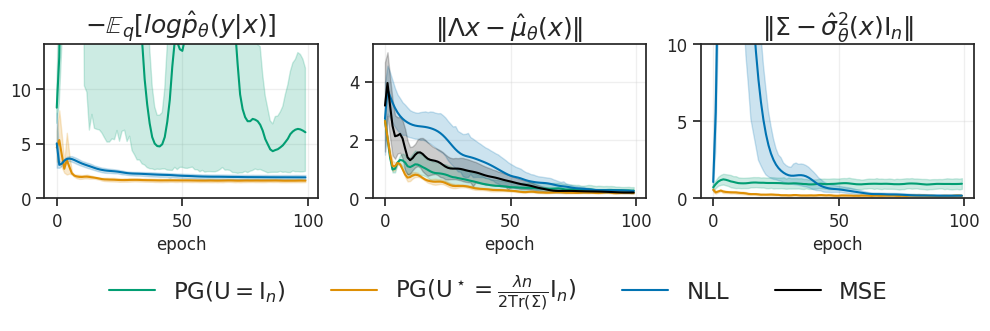

In [12]:
sub_df = df_all.copy()

palette = {
    # "A": "#0173B2",
    "PG($\\mathrm{U}=\\mathrm{I}_n$)": "#029E73",
    "PG($\\mathrm{U}^\\star=\\frac{\\lambda n}{2 \\operatorname{Tr}(\\Sigma)}\\mathrm{I}_n$)": "#DE8F05",
}

metric_name = []
metric_name.append(("NLL", r"$-\mathbb{E}_q[log\hat{p}_\theta(y|x)]$"))
metric_name.append(("mean_error", r"$\|\Lambda x-\hat{\mu}_\theta(x)\|$"))
metric_name.append(
    ("sigma_error", r"$\|\Sigma-\hat{\sigma}^2_\theta(x) \mathrm{I}_n\|$")
)

_, ax = plt.subplots(1, len(metric_name), figsize=(12, 2), gridspec_kw=dict(wspace=0.2))
for i, (metric, name) in enumerate(metric_name):
    sns.lineplot(
        data=sub_df[sub_df["train_val"] == "val"],
        x="epoch",
        y=metric,
        hue="U",
        ax=ax[i],
        legend=False if i != 1 else True,
        errorbar=("ci", 95),
        palette=palette
    )
    sns.lineplot(
        data=sub_df[sub_df["loss_type"] == "NLL"],
        x="epoch",
        y=metric,
        ax=ax[i],
        color="#0173B2",
        label="NLL" if i == 1 else None,
        errorbar=("ci", 95),
    )
    if metric == "mean_error":
        sns.lineplot(
            data=sub_df[sub_df["loss_type"] == "MSE"],
            x="epoch",
            y=metric,
            ax=ax[i],
            color="black",
            label="MSE" if i == 1 else None,
            errorbar=("ci", 95),
        )
    max_for_lim = sub_df[sub_df["loss_type"] == "NLL"][metric].max()
    ax[i].set_ylim(
        min(sub_df[sub_df["loss_type"] == "NLL"][metric].min(), 0.0),
        max_for_lim if metric != "sigma_error" else 10,  # + max_for_lim / 2,
    )
    ax[i].set_ylabel(None)
    ax[i].set_title(name)
    ax[i].tick_params(axis="y", labelsize=12)
    ax[i].tick_params(axis="x", labelsize=12)
    ax[i].set_xlabel("epoch", fontsize=12)
    ax[i].locator_params(axis="y", nbins=3)
    ax[i].locator_params(axis="x", nbins=3)
    ax[i].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"{x:.0f}"))
    ax[i].grid(True, alpha=0.3)
ax[1].legend(bbox_to_anchor=(0.46, -0.87), loc="lower center", ncol=4, frameon=False)
os.makedirs("../figures", exist_ok=True)
plt.savefig("../figures/toy_avg.pdf", bbox_inches="tight")
plt.show()